In [56]:
import warnings
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [57]:
# Step 1 - Load and merge LR/SR inventories across tiles, then enrich from combined inventories when available.
repo_root = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution")
dataset_dir = repo_root / "yellowness_dataset"

lr_files = sorted(Path(p) for p in glob.glob(str(dataset_dir / "**" / "lr_inventory*.csv"), recursive=True))
sr_files = sorted(Path(p) for p in glob.glob(str(dataset_dir / "**" / "sr_inventory*.csv"), recursive=True))
combined_files = sorted(dataset_dir.glob("**/observations_inventory*.csv"))

if not lr_files or not sr_files:
    raise FileNotFoundError("Missing LR/SR inventory CSV files in yellowness_dataset.")

def load_inventory(files, label):
    parts = []
    for file_path in files:
        tmp = pd.read_csv(file_path)
        tmp["source_inventory"] = label
        tmp["source_file"] = str(file_path.relative_to(repo_root))
        parts.append(tmp)
    return pd.concat(parts, ignore_index=True)

def keyset_fallback(df_a, df_b):
    candidates = [
        ["id_plot", "observation_date", "s2_acquisition_date"],
        ["id_plot", "observation_date"],
        ["id_plot", "s2_acquisition_date"],
        ["id_plot", "s2_date"],
        ["id_plot", "month", "day_of_year"],
    ]
    for keys in candidates:
        if all(k in df_a.columns and k in df_b.columns for k in keys):
            return keys
    common = [k for k in ["id_plot", "observation_date", "s2_acquisition_date", "s2_date"] if k in df_a.columns and k in df_b.columns]
    if not common:
        raise ValueError("No shared keys between CSVs for merge.")
    return common

def dedupe_by_best_keys(df):
    candidates = [
        ["id_plot", "observation_date", "s2_acquisition_date"],
        ["id_plot", "observation_date"],
        ["id_plot", "s2_acquisition_date"],
        ["id_plot", "s2_date"],
    ]
    for keys in candidates:
        if all(k in df.columns for k in keys):
            return df.drop_duplicates(subset=keys, keep="last")
    return df.drop_duplicates(keep="last")

lr_df = dedupe_by_best_keys(load_inventory(lr_files, "lr"))
sr_df = dedupe_by_best_keys(load_inventory(sr_files, "sr"))

join_keys = keyset_fallback(lr_df, sr_df)
df = pd.merge(lr_df, sr_df, on=join_keys, how="inner", suffixes=("_lrdup", "_srdup"))

if combined_files:
    combined_parts = [pd.read_csv(p) for p in combined_files]
    combined_df = dedupe_by_best_keys(pd.concat(combined_parts, ignore_index=True))
    enrich_keys = keyset_fallback(df, combined_df)
    new_cols = [c for c in combined_df.columns if c not in df.columns or c in enrich_keys]
    df = pd.merge(df, combined_df[new_cols], on=enrich_keys, how="left", suffixes=("", "_combineddup"))

drop_suffixes = ("_lrdup", "_srdup", "_combineddup")
df = df.drop(columns=[c for c in df.columns if c.endswith(drop_suffixes)], errors="ignore")
df = df.loc[:, ~df.columns.duplicated()].copy()

for date_col in ["observation_date", "s2_acquisition_date", "s2_date"]:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

print(f"LR files: {len(lr_files)}")
print(f"SR files: {len(sr_files)}")
print(f"Combined files: {len(combined_files)}")
print(f"Join keys used: {join_keys}")
print(f"Merged shape: {df.shape}")
display(df.head())

LR files: 1
SR files: 1
Combined files: 1
Join keys used: ['id_plot', 'observation_date', 's2_acquisition_date']
Merged shape: (338, 115)


,id_plot,observation_date,s2_acquisition_date,lr_image_path,lr_mask_path,lr_NDRE_mean,lr_NDRE_std,lr_NDYVI_mean,lr_NDYVI_std,lr_GCC_mean,...,parcel_area_ha,month,day_of_year,s2_date_difference_days,day_offset,yellowness,lr_patch,sr_patch,lr_mask,sr_mask
0,16575797,2020-06-08,2020-06-09,images_lr\lr_plot_16575797_obs_2020-06-08.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.230113,0.095358,-0.059414,0.126788,0.359409,...,0.001986,6,161,1,1,0.0,images_lr\lr_plot_16575797_obs_2020-06-08.tif,images_sr\sr_plot_16575797_obs_2020-06-08.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
1,16575797,2020-06-15,2020-06-14,images_lr\lr_plot_16575797_obs_2020-06-15.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.252225,0.094446,-0.032131,0.126343,0.362927,...,0.001986,6,166,1,1,0.0,images_lr\lr_plot_16575797_obs_2020-06-15.tif,images_sr\sr_plot_16575797_obs_2020-06-15.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
2,16575797,2020-06-22,2020-06-24,images_lr\lr_plot_16575797_obs_2020-06-22.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.299800,0.098380,0.029258,0.132714,0.371741,...,0.001986,6,176,2,2,1.0,images_lr\lr_plot_16575797_obs_2020-06-22.tif,images_sr\sr_plot_16575797_obs_2020-06-22.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
3,16575797,2020-07-06,2020-07-04,images_lr\lr_plot_16575797_obs_2020-07-06.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.365589,0.090121,0.115880,0.126189,0.382710,...,0.001986,7,186,2,2,10.0,images_lr\lr_plot_16575797_obs_2020-07-06.tif,images_sr\sr_plot_16575797_obs_2020-07-06.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
4,16575797,2020-07-13,2020-07-14,images_lr\lr_plot_16575797_obs_2020-07-13.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.430086,0.087577,0.207789,0.126229,0.398360,...,0.001986,7,196,1,1,15.0,images_lr\lr_plot_16575797_obs_2020-07-13.tif,images_sr\sr_plot_16575797_obs_2020-07-13.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif


In [58]:
# Step 2 - Dataset overview
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Parcels:", df["id_plot"].nunique() if "id_plot" in df.columns else "N/A")

if "id_plot" in df.columns:
    obs_stats = df.groupby("id_plot").size().describe()
    print("\nObservations per parcel (describe):")
    display(obs_stats)

if "yellowness" in df.columns:
    print("\nTarget missing values:", int(df["yellowness"].isna().sum()))
    print("Target describe:")
    display(df["yellowness"].describe())

Rows: 338
Columns: 115
Parcels: 91

Observations per parcel (describe):


count    91.000000
mean      3.714286
std       3.587899
min       1.000000
25%       1.000000
50%       2.000000
75%       5.000000
max      14.000000
dtype: float64


Target missing values: 0
Target describe:


count    338.000000
mean      46.148817
std       39.157011
min        0.000000
25%        5.000000
50%       40.000000
75%       88.750000
max      100.000000
Name: yellowness, dtype: float64

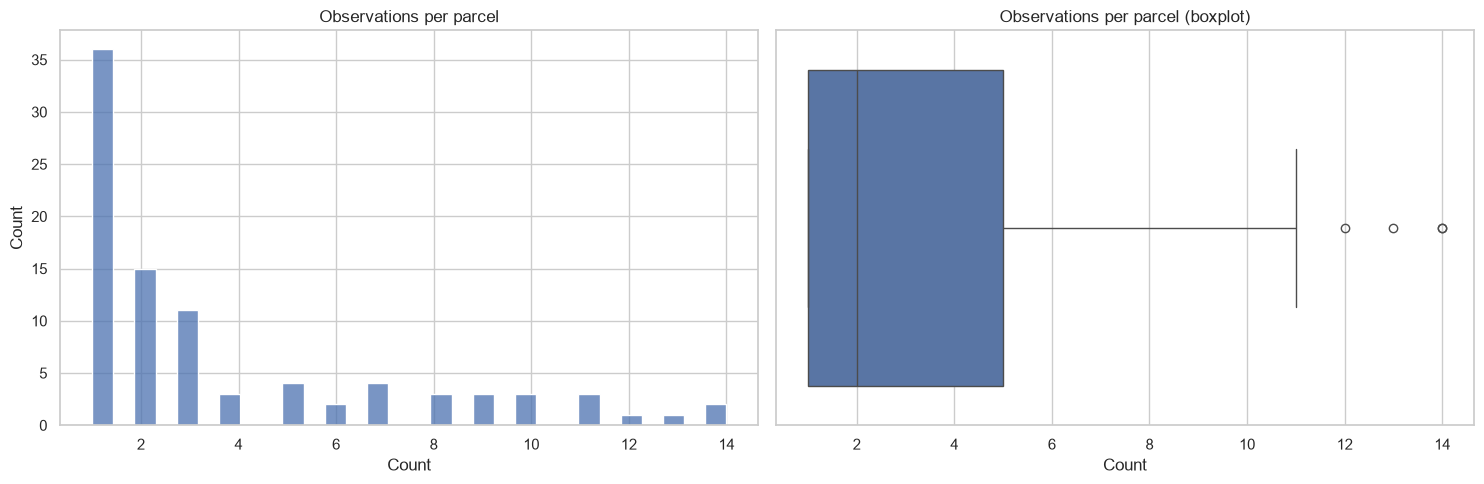

In [47]:
# Step 3 - Data exploration: observations per parcel
if "id_plot" not in df.columns:
    raise ValueError("id_plot column is required for grouped exploration.")

obs_per_parcel = df.groupby("id_plot").size()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(obs_per_parcel, bins=30, ax=ax[0])
ax[0].set_title("Observations per parcel")
ax[0].set_xlabel("Count")

sns.boxplot(x=obs_per_parcel, ax=ax[1])
ax[1].set_title("Observations per parcel (boxplot)")
ax[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

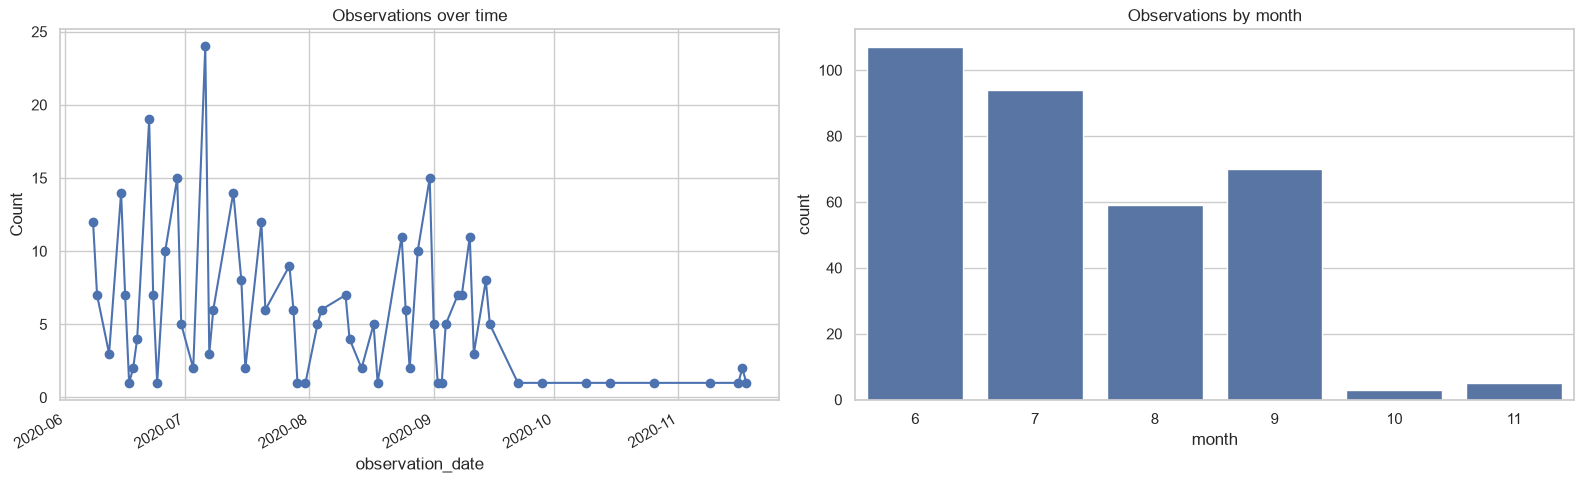

In [59]:
# Step 4 - Temporal exploration
date_col = "observation_date" if "observation_date" in df.columns else None
if date_col is None:
    raise ValueError("No observation_date column available for temporal plot.")

daily_counts = df.groupby(date_col).size().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
daily_counts.plot(marker="o", linewidth=1.5, ax=ax[0])
ax[0].set_title("Observations over time")
ax[0].set_ylabel("Count")

if "month" in df.columns:
    sns.countplot(data=df, x="month", order=sorted(df["month"].dropna().unique()), ax=ax[1])
    ax[1].set_title("Observations by month")
else:
    ax[1].text(0.5, 0.5, "month column unavailable", ha="center", va="center")
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()

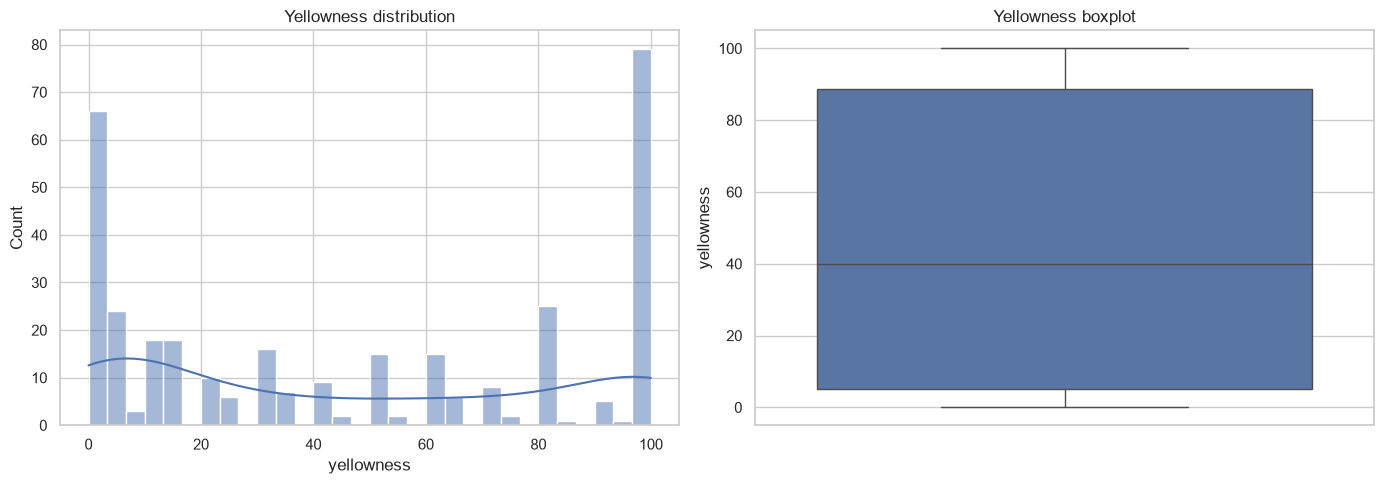

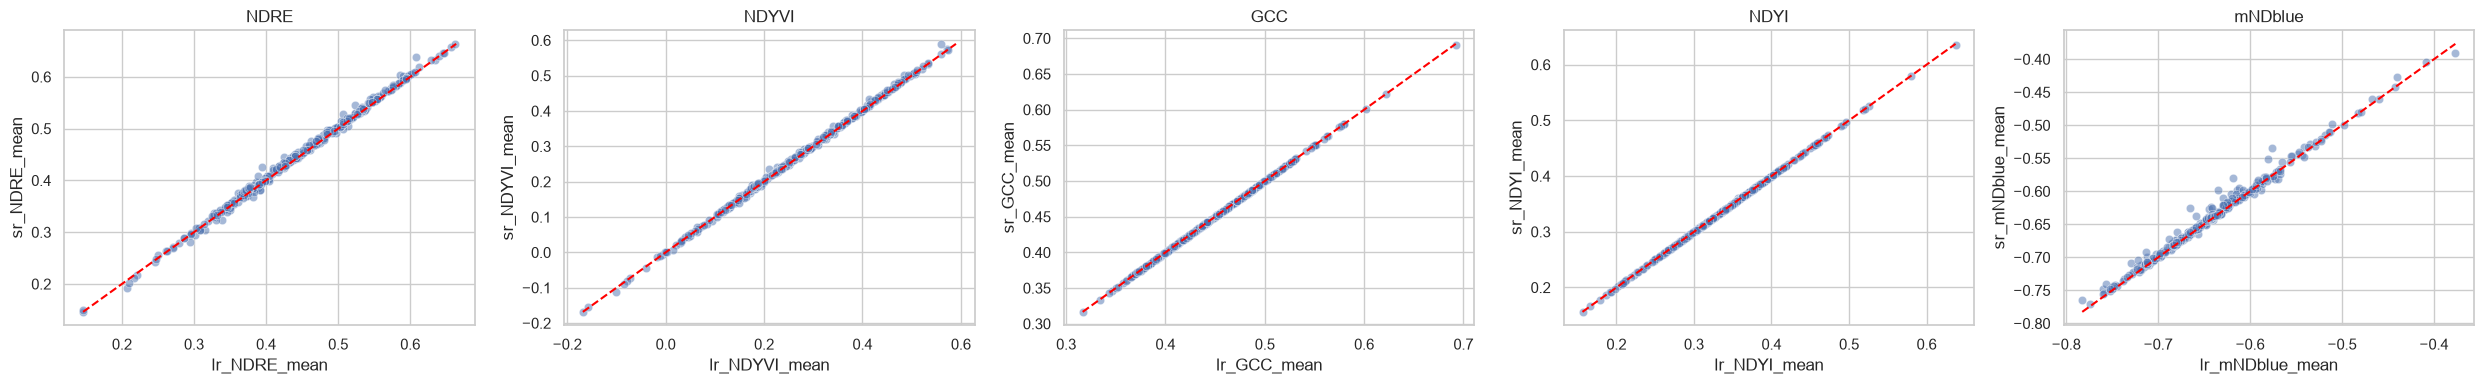

In [48]:
# Step 5 - Target distribution and LR/SR index agreement
if "yellowness" not in df.columns:
    raise ValueError("yellowness column is required.")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["yellowness"].dropna(), bins=30, kde=True, ax=ax[0])
ax[0].set_title("Yellowness distribution")

sns.boxplot(y=df["yellowness"], ax=ax[1])
ax[1].set_title("Yellowness boxplot")

plt.tight_layout()
plt.show()

indices = ["NDRE", "NDYVI", "GCC", "NDYI", "mNDblue"]
available_pairs = [(f"lr_{idx}_mean", f"sr_{idx}_mean", idx) for idx in indices if f"lr_{idx}_mean" in df.columns and f"sr_{idx}_mean" in df.columns]

if available_pairs:
    n = len(available_pairs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (lr_col, sr_col, label) in zip(axes, available_pairs):
        sns.scatterplot(data=df, x=lr_col, y=sr_col, alpha=0.5, ax=ax)
        lims = [
            np.nanmin([df[lr_col].min(), df[sr_col].min()]),
            np.nanmax([df[lr_col].max(), df[sr_col].max()]),
        ]
        ax.plot(lims, lims, color="red", linestyle="--")
        ax.set_title(label)
    plt.tight_layout()
    plt.show()

LR dataframe preview:


,year,parcel_area_m2,parcel_area_ha,month,day_of_year,s2_date_difference_days,id_plot,observation_date,s2_acquisition_date,day_offset,...,lr_RE_slope_740_783_mean,lr_RE_slope_740_783_std,lr_RE_slope_783_865_mean,lr_RE_slope_783_865_std,lr_RE_curvature_705_740_783_mean,lr_RE_curvature_705_740_783_std,lr_RE_curvature_740_783_865_mean,lr_RE_curvature_740_783_865_std,source_inventory,source_file
0,2020,19.86,0.001986,6,161,1,16575797,2020-06-08,2020-06-09,1,...,0.000658,0.000234,0.000253,0.000034,-0.096264,0.032330,-0.007550,0.011438,lr,yellowness_dataset\lr_inventory.csv
1,2020,19.86,0.001986,6,166,1,16575797,2020-06-15,2020-06-14,1,...,0.000706,0.000232,0.000256,0.000033,-0.105240,0.029586,-0.009345,0.011338,lr,yellowness_dataset\lr_inventory.csv
2,2020,19.86,0.001986,6,176,2,16575797,2020-06-22,2020-06-24,2,...,0.000803,0.000256,0.000264,0.000039,-0.123191,0.026614,-0.012933,0.012572,lr,yellowness_dataset\lr_inventory.csv
3,2020,19.86,0.001986,7,186,2,16575797,2020-07-06,2020-07-04,2,...,0.001078,0.000233,0.000269,0.000041,-0.148592,0.024719,-0.024280,0.012187,lr,yellowness_dataset\lr_inventory.csv
4,2020,19.86,0.001986,7,196,1,16575797,2020-07-13,2020-07-14,1,...,0.001352,0.000237,0.000275,0.000056,-0.173996,0.030236,-0.035625,0.013679,lr,yellowness_dataset\lr_inventory.csv


SR dataframe preview:


,year,parcel_area_m2,parcel_area_ha,month,day_of_year,s2_date_difference_days,id_plot,observation_date,s2_acquisition_date,day_offset,...,sr_RE_slope_740_783_mean,sr_RE_slope_740_783_std,sr_RE_slope_783_865_mean,sr_RE_slope_783_865_std,sr_RE_curvature_705_740_783_mean,sr_RE_curvature_705_740_783_std,sr_RE_curvature_740_783_865_mean,sr_RE_curvature_740_783_865_std,source_inventory,source_file
0,2020,19.86,0.001986,6,161,1,16575797,2020-06-08,2020-06-09,1,...,0.000679,0.000282,0.000262,0.000054,-0.092695,0.036289,-0.007747,0.010649,sr,yellowness_dataset\sr_inventory.csv
1,2020,19.86,0.001986,6,166,1,16575797,2020-06-15,2020-06-14,1,...,0.000730,0.000268,0.000274,0.000056,-0.101804,0.033181,-0.008894,0.010325,sr,yellowness_dataset\sr_inventory.csv
2,2020,19.86,0.001986,6,176,2,16575797,2020-06-22,2020-06-24,2,...,0.000828,0.000280,0.000299,0.000069,-0.120138,0.029412,-0.011088,0.011440,sr,yellowness_dataset\sr_inventory.csv
3,2020,19.86,0.001986,7,186,2,16575797,2020-07-06,2020-07-04,2,...,0.001105,0.000289,0.000313,0.000073,-0.145800,0.027693,-0.021850,0.013218,sr,yellowness_dataset\sr_inventory.csv
4,2020,19.86,0.001986,7,196,1,16575797,2020-07-13,2020-07-14,1,...,0.001385,0.000347,0.000327,0.000091,-0.171459,0.034081,-0.032738,0.017306,sr,yellowness_dataset\sr_inventory.csv


LR full pool: 48
SR full pool: 48


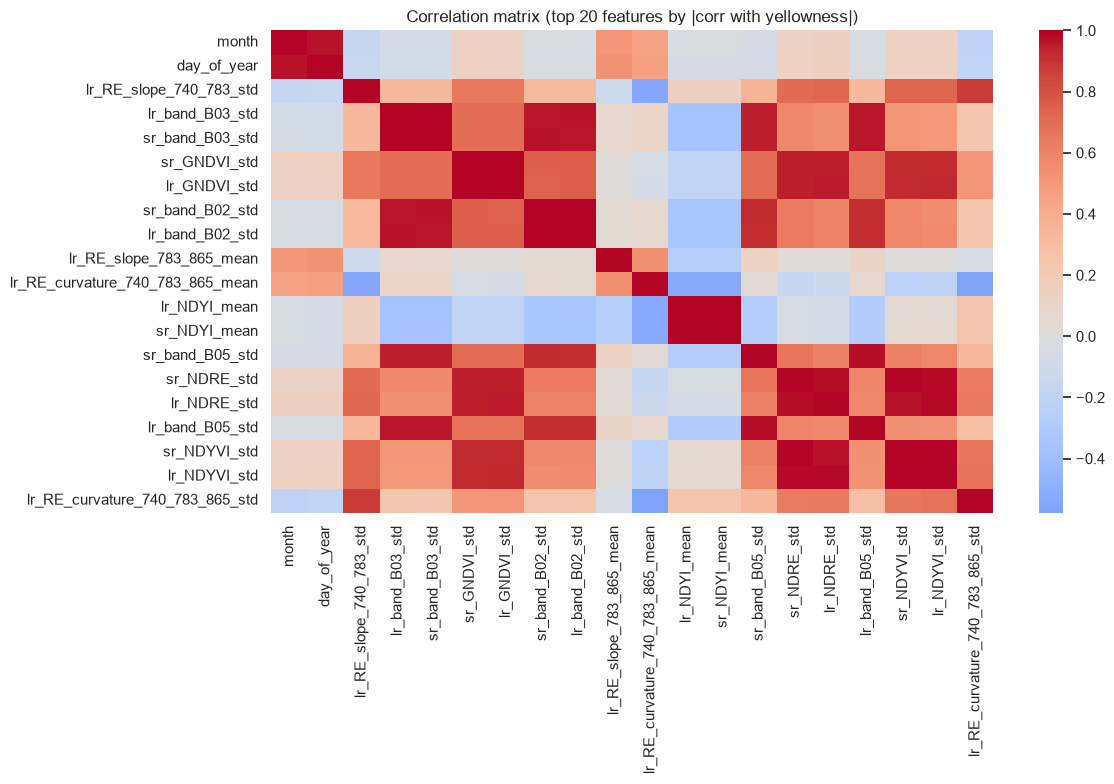

After collinearity filter:
LR decorrelated pool: 37
SR decorrelated pool: 37


In [60]:
# Step 6 - Feature pools, covariance, and collinearity filtering (LR and SR only)
target = "yellowness"

print("LR dataframe preview:")
display(lr_df.head())
print("SR dataframe preview:")
display(sr_df.head())

excluded_exact = {
    "year", "parcel_index", "id_plot", target, "source_file", "source_inventory"
}
excluded_keywords = (
    "patch", "mask", "observation_column", "stack_name", "observation_date", "s2_date",
    "valid_pixels", "valid_fill_ratio", "geometry_area"
)

numeric_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c not in excluded_exact and df[c].nunique(dropna=True) > 1
]

def keep_feature(col):
    return not any(k in col for k in excluded_keywords)

filtered_numeric_cols = [c for c in numeric_cols if keep_feature(c)]
meta_features = [c for c in ["month", "day_of_year", "s2_date_difference_days"] if c in filtered_numeric_cols]

lr_full_pool = [c for c in filtered_numeric_cols if c.startswith(("lr_", "calc_lr_"))]
sr_full_pool = [c for c in filtered_numeric_cols if c.startswith(("sr_", "calc_sr_"))]

print("LR full pool:", len(lr_full_pool))
print("SR full pool:", len(sr_full_pool))

# Covariance/correlation view on top target-correlated features.
corr_with_target = df[filtered_numeric_cols + [target]].corr(numeric_only=True)[target].drop(target).dropna()
top_corr_features = corr_with_target.abs().sort_values(ascending=False).head(20).index.tolist()

if top_corr_features:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[top_corr_features].corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Correlation matrix (top 20 features by |corr with yellowness|)")
    plt.tight_layout()
    plt.show()

def drop_high_corr(columns, threshold=0.98):
    if len(columns) <= 1:
        return columns
    corr_mat = df[columns].corr(numeric_only=True).abs()
    upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in columns if c not in to_drop]

lr_decor_pool = drop_high_corr(lr_full_pool)
sr_decor_pool = drop_high_corr(sr_full_pool)

print("After collinearity filter:")
print("LR decorrelated pool:", len(lr_decor_pool))
print("SR decorrelated pool:", len(sr_decor_pool))

In [61]:
# Step 7 - Grouped split by id_plot + important decorrelated features only
if "id_plot" not in df.columns:
    raise ValueError("id_plot is required for grouped split.")

splitter = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["id_plot"]))
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train parcels:", train_df["id_plot"].nunique(), "| Test parcels:", test_df["id_plot"].nunique())
print("Overlap parcels:", len(set(train_df["id_plot"]) & set(test_df["id_plot"])))

# Use only decorrelated pools provided by Step 6.
base_feature_groups = {
    "LR": sorted(set(lr_decor_pool + meta_features)),
    "SR": sorted(set(sr_decor_pool + meta_features)),
}

def prepare_important_decorrelated_set(train_frame, test_frame, features, top_k=40):
    X_train_raw = train_frame[features].copy()
    X_test_raw = test_frame[features].copy()
    y_train = train_frame[target].astype(float).copy()
    y_test = test_frame[target].astype(float).copy()

    medians = X_train_raw.median(numeric_only=True)
    X_train_raw = X_train_raw.fillna(medians)
    X_test_raw = X_test_raw.fillna(medians)

    if X_train_raw.shape[1] == 0:
        return None

    k = min(top_k, X_train_raw.shape[1])
    mi = mutual_info_regression(X_train_raw, y_train, random_state=42)
    mi_series = pd.Series(mi, index=X_train_raw.columns).sort_values(ascending=False)
    selected = mi_series.head(k).index.tolist()

    return {
        "X_train": X_train_raw[selected],
        "X_test": X_test_raw[selected],
        "y_train": y_train,
        "y_test": y_test,
        "selected_features": selected,
        "mi_scores": mi_series,
    }

prepared_sets = {}
selected_features_summary = {}
TOP_K_IMPORTANT = 40

for feature_group, cols in base_feature_groups.items():
    if len(cols) == 0:
        continue
    dataset_key = f"{feature_group}|important_decorrelated"
    prepared = prepare_important_decorrelated_set(train_df, test_df, cols, top_k=TOP_K_IMPORTANT)
    if prepared is None:
        continue
    prepared_sets[dataset_key] = prepared
    selected_features_summary[dataset_key] = prepared["selected_features"]
    print(f"{dataset_key}: {len(cols)} decorrelated candidates -> {len(prepared['selected_features'])} important features")

if not prepared_sets:
    raise ValueError("No valid important decorrelated datasets prepared.")

print("\nSelected feature examples:")
for key, feat_list in selected_features_summary.items():
    print(f"{key}: {feat_list[:10]}{' ...' if len(feat_list) > 10 else ''}")

Train rows: 270 | Test rows: 68
Train parcels: 72 | Test parcels: 19
Overlap parcels: 0
LR|important_decorrelated: 39 decorrelated candidates -> 39 important features
SR|important_decorrelated: 39 decorrelated candidates -> 39 important features

Selected feature examples:
LR|important_decorrelated: ['lr_band_B11_mean', 'month', 'day_of_year', 'lr_RE_slope_705_740_mean', 'lr_band_B12_mean', 'lr_NDMI_std', 'lr_NDYI_std', 'lr_GCC_mean', 'lr_NDRE_std', 'lr_RE_slope_740_783_mean'] ...
SR|important_decorrelated: ['month', 'day_of_year', 'sr_RE_slope_783_865_mean', 'sr_band_B12_mean', 'sr_band_B11_mean', 'sr_GCC_mean', 'sr_NDMI_mean', 'sr_RE_curvature_740_783_865_std', 'sr_RE_slope_705_740_mean', 'sr_band_B05_std'] ...


In [62]:
# Step 8 - Model training on important decorrelated feature sets
models = {
    "Ridge": Pipeline([("model", Ridge(alpha=1.0))]),
    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": Pipeline([("model", SVR(C=1.0, epsilon=0.1, kernel="rbf"))]),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror",
        random_state=42, n_jobs=-1,
    ),
}

results = []
trained_models = {}

for dataset_key, payload in prepared_sets.items():
    feature_group, strategy = dataset_key.split("|")
    X_train = payload["X_train"]
    X_test = payload["X_test"]
    y_train = payload["y_train"]
    y_test = payload["y_test"]

    for model_name, model in models.items():
        fitted = clone(model).fit(X_train, y_train)
        pred = fitted.predict(X_test)
        rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
        mae = float(mean_absolute_error(y_test, pred))
        r2 = float(r2_score(y_test, pred))

        results.append({
            "Feature_Group": feature_group,
            "Strategy": strategy,
            "Dataset": dataset_key,
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "n_features": X_train.shape[1],
        })
        trained_models[(dataset_key, model_name)] = fitted

results_df = pd.DataFrame(results).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
display(results_df)

best_config = results_df.iloc[0]
print("Best config:")
display(best_config.to_frame().T)

,Feature_Group,Strategy,Dataset,Model,MAE,RMSE,R2,n_features
0,LR,important_decorrelated,LR|important_decorrelated,XGBoost,20.610577,27.948805,0.506493,39
1,SR,important_decorrelated,SR|important_decorrelated,GradientBoosting,20.723540,28.070573,0.502184,39
2,LR,important_decorrelated,LR|important_decorrelated,ExtraTrees,21.998452,28.861594,0.473732,39
3,SR,important_decorrelated,SR|important_decorrelated,ExtraTrees,21.493085,29.235551,0.460006,39
4,LR,important_decorrelated,LR|important_decorrelated,RandomForest,22.252510,29.382198,0.454575,39
5,LR,important_decorrelated,LR|important_decorrelated,GradientBoosting,21.649065,29.445477,0.452223,39
6,SR,important_decorrelated,SR|important_decorrelated,XGBoost,22.577186,30.427699,0.415069,39
7,SR,important_decorrelated,SR|important_decorrelated,RandomForest,22.404135,30.574247,0.409421,39
8,LR,important_decorrelated,LR|important_decorrelated,Ridge,28.635686,33.559964,0.288443,39
9,SR,important_decorrelated,SR|important_decorrelated,Ridge,28.964327,33.991126,0.270042,39


Best config:


,Feature_Group,Strategy,Dataset,Model,MAE,RMSE,R2,n_features
0,LR,important_decorrelated,LR|important_decorrelated,XGBoost,20.610577,27.948805,0.506493,39


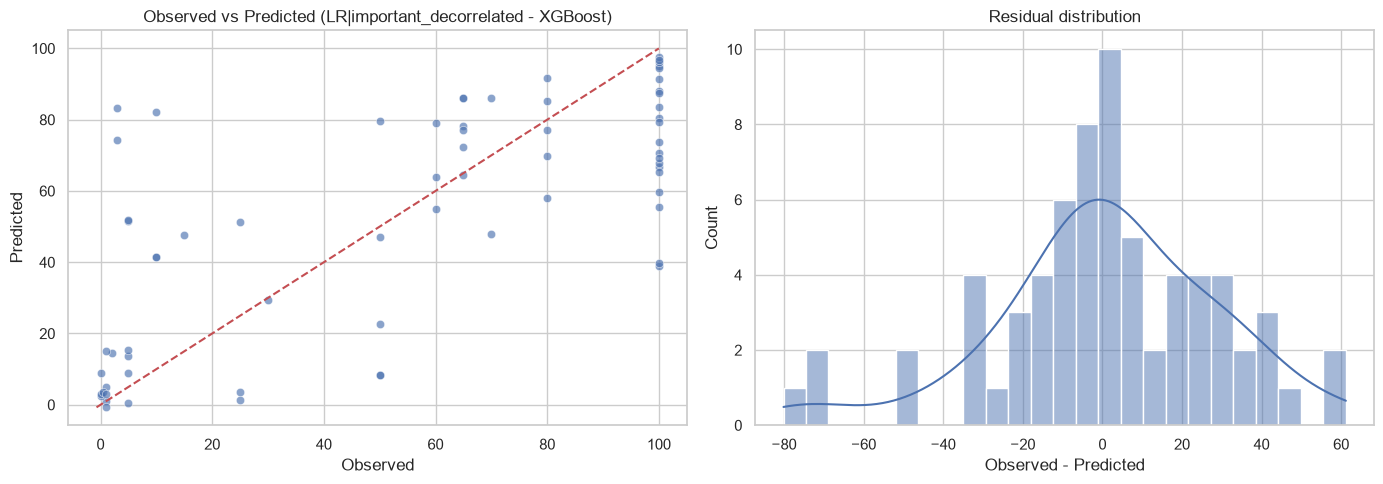

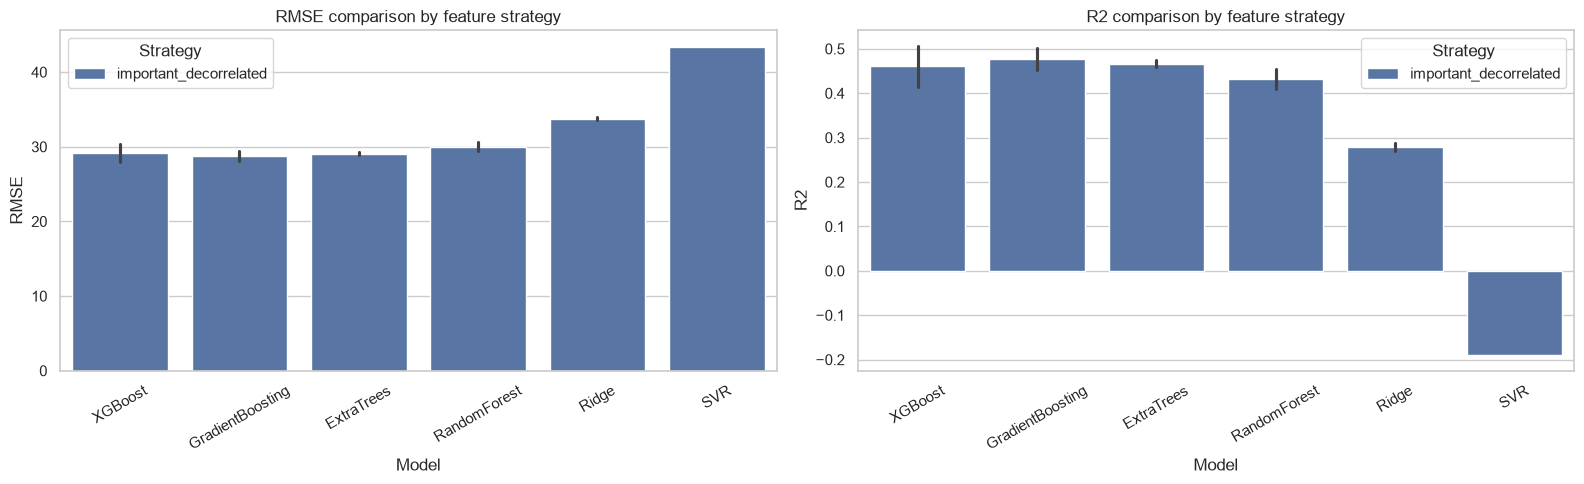

In [63]:
# Step 9 - Model evaluation
best_dataset = best_config["Dataset"]
best_model_name = best_config["Model"]
best_model = trained_models[(best_dataset, best_model_name)]

X_test_best = prepared_sets[best_dataset]["X_test"]
y_test_best = prepared_sets[best_dataset]["y_test"]
y_pred_best = best_model.predict(X_test_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test_best, y=y_pred_best, alpha=0.65, ax=axes[0])
lims = [min(y_test_best.min(), y_pred_best.min()), max(y_test_best.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_title(f"Observed vs Predicted ({best_dataset} - {best_model_name})")
axes[0].set_xlabel("Observed")
axes[0].set_ylabel("Predicted")

residuals = y_test_best - y_pred_best
sns.histplot(residuals, bins=25, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Observed - Predicted")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", hue="Strategy", ax=axes[0])
axes[0].set_title("RMSE comparison by feature strategy")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=results_df, x="Model", y="R2", hue="Strategy", ax=axes[1])
axes[1].set_title("R2 comparison by feature strategy")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [64]:
# Step 10 - Classification setup: create 3 yellowness classes and train classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

df_class = df.copy()
class_bins = [0, 30.0, 60.0, 100.0]
class_labels = ["low", "medium", "high"]
df_class["yellowness_class"] = pd.cut(
    df_class["yellowness"],
    bins=class_bins,
    labels=class_labels,
    include_lowest=True,
    ordered=True,
).astype(str)

print("Class distribution:")
display(df_class["yellowness_class"].value_counts(dropna=False).rename_axis("class").to_frame("count"))

classification_feature_sets = {}
for dataset_key, feature_list in selected_features_summary.items():
    feature_group = dataset_key.split("|")[0]
    classification_feature_sets[feature_group] = feature_list

cls_splitter = GroupShuffleSplit(test_size=0.2, random_state=42)
cls_train_idx, cls_test_idx = next(cls_splitter.split(df_class, groups=df_class["id_plot"]))
train_cls_df = df_class.iloc[cls_train_idx].copy()
test_cls_df = df_class.iloc[cls_test_idx].copy()

print("Classification train parcels:", train_cls_df["id_plot"].nunique())
print("Classification test parcels:", test_cls_df["id_plot"].nunique())
print("Classification parcel overlap:", len(set(train_cls_df["id_plot"]) & set(test_cls_df["id_plot"])))

classification_models = {
    "LogisticRegression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"),
    "ExtraTreesClassifier": ExtraTreesClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "SVC": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1.0, class_weight="balanced"))]),
}

classification_results = []
trained_classifiers = {}

for feature_group, feature_list in classification_feature_sets.items():
    X_train_cls = train_cls_df[feature_list].copy()
    X_test_cls = test_cls_df[feature_list].copy()
    y_train_cls = train_cls_df["yellowness_class"].copy()
    y_test_cls = test_cls_df["yellowness_class"].copy()

    medians = X_train_cls.median(numeric_only=True)
    X_train_cls = X_train_cls.fillna(medians)
    X_test_cls = X_test_cls.fillna(medians)

    for model_name, model in classification_models.items():
        fitted_model = clone(model).fit(X_train_cls, y_train_cls)
        y_pred_cls = fitted_model.predict(X_test_cls)

        classification_results.append({
            "Feature_Group": feature_group,
            "Model": model_name,
            "Accuracy": float(accuracy_score(y_test_cls, y_pred_cls)),
            "Balanced_Accuracy": float(balanced_accuracy_score(y_test_cls, y_pred_cls)),
            "F1_Macro": float(f1_score(y_test_cls, y_pred_cls, average="macro")),
            "n_features": X_train_cls.shape[1],
        })
        trained_classifiers[(feature_group, model_name)] = fitted_model

classification_results_df = pd.DataFrame(classification_results).sort_values(["F1_Macro", "Balanced_Accuracy", "Accuracy"], ascending=False).reset_index(drop=True)
display(classification_results_df)

best_classification_config = classification_results_df.iloc[0]
print("Best classification config:")
display(best_classification_config.to_frame().T)

Class distribution:


,count
class,
low,160
high,127
medium,51


Classification train parcels: 72
Classification test parcels: 19
Classification parcel overlap: 0


,Feature_Group,Model,Accuracy,Balanced_Accuracy,F1_Macro,n_features
0,LR,ExtraTreesClassifier,0.764706,0.570136,0.543810,39
1,SR,ExtraTreesClassifier,0.750000,0.560332,0.531966,39
2,LR,RandomForestClassifier,0.735294,0.547511,0.528889,39
3,LR,SVC,0.705882,0.521870,0.519216,39
4,SR,RandomForestClassifier,0.720588,0.537707,0.518636,39
5,SR,LogisticRegression,0.661765,0.495475,0.509604,39
6,LR,GradientBoostingClassifier,0.720588,0.537707,0.508541,39
7,LR,LogisticRegression,0.602941,0.479072,0.502696,39
8,SR,SVC,0.647059,0.482655,0.495998,39
9,SR,GradientBoostingClassifier,0.676471,0.508296,0.483333,39


Best classification config:


,Feature_Group,Model,Accuracy,Balanced_Accuracy,F1_Macro,n_features
0,LR,ExtraTreesClassifier,0.764706,0.570136,0.54381,39


              precision    recall  f1-score   support

        high       0.82      0.94      0.88        34
         low       0.74      0.77      0.75        26
      medium       0.00      0.00      0.00         8

    accuracy                           0.76        68
   macro avg       0.52      0.57      0.54        68
weighted avg       0.69      0.76      0.73        68



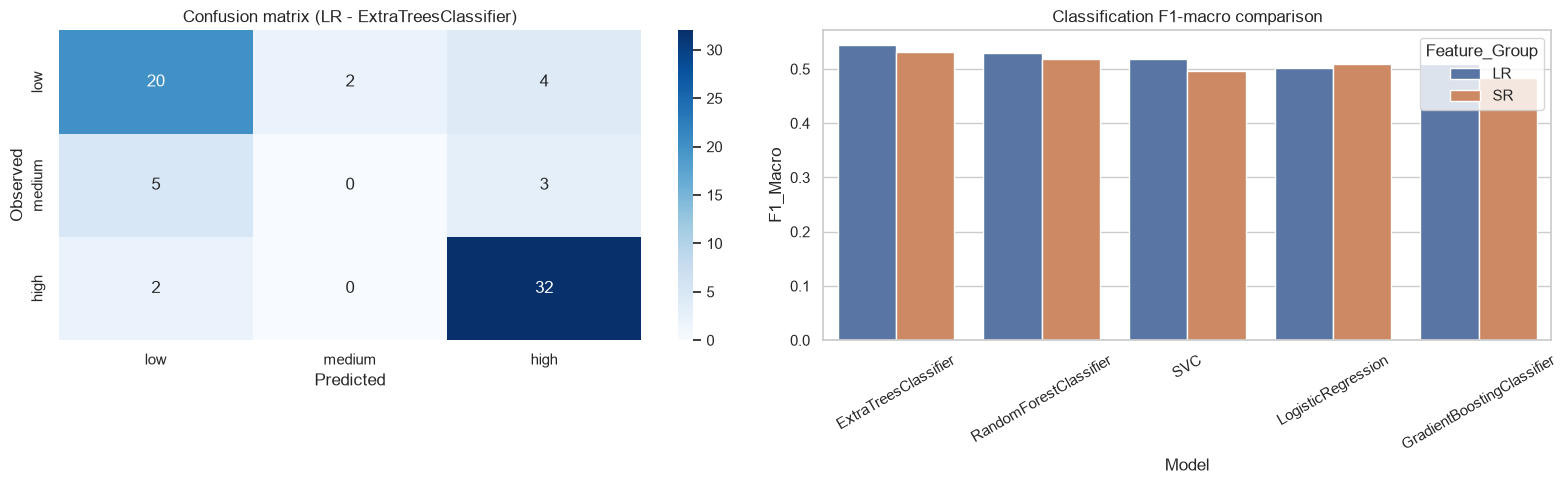

In [65]:
# Step 11 - Classification evaluation
best_cls_group = best_classification_config["Feature_Group"]
best_cls_model_name = best_classification_config["Model"]
best_classifier = trained_classifiers[(best_cls_group, best_cls_model_name)]

best_cls_features = classification_feature_sets[best_cls_group]
X_test_cls_best = test_cls_df[best_cls_features].copy()
X_test_cls_best = X_test_cls_best.fillna(train_cls_df[best_cls_features].median(numeric_only=True))
y_test_cls_best = test_cls_df["yellowness_class"].copy()
y_pred_cls_best = best_classifier.predict(X_test_cls_best)

print(classification_report(y_test_cls_best, y_pred_cls_best))

cm = confusion_matrix(y_test_cls_best, y_pred_cls_best, labels=class_labels)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title(f"Confusion matrix ({best_cls_group} - {best_cls_model_name})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Observed")

sns.barplot(data=classification_results_df, x="Model", y="F1_Macro", hue="Feature_Group", ax=axes[1])
axes[1].set_title("Classification F1-macro comparison")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()